# Correlation Analysis

In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd
# as_frame=True로 바로 DataFrame 형태로 받기
boston = fetch_openml(name="boston", version=1, as_frame=True)
X = boston.data          # 특성
y = boston.target        # 타깃(MEDV)
df = pd.concat([X, y.rename("MEDV")], axis=1)
print(df.shape)
print(df.head())

(506, 14)
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [3]:
# 3. 기본 정보 확인
print(df.describe())



             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.554695    6.284634   68.574901   
std      8.601545   23.322453    6.860353    0.115878    0.702617   28.148861   
min      0.006320    0.000000    0.460000    0.385000    3.561000    2.900000   
25%      0.082045    0.000000    5.190000    0.449000    5.885500   45.025000   
50%      0.256510    0.000000    9.690000    0.538000    6.208500   77.500000   
75%      3.677083   12.500000   18.100000    0.624000    6.623500   94.075000   
max     88.976200  100.000000   27.740000    0.871000    8.780000  100.000000   

              DIS         TAX     PTRATIO           B       LSTAT        MEDV  
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  
mean     3.795043  408.237154   18.455534  356.674032   12.653063   22.532806  
std      2.105710  168.537116 

In [4]:
# 4. 상관계수 행렬 계산
corr_matrix = df.corr()
print(corr_matrix)

             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
ZN      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
INDUS    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
CHAS    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
NOX      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
RM      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
AGE      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
DIS     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
RAD      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
TAX      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
PTRATIO  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
B       -0.385064  0.175520 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


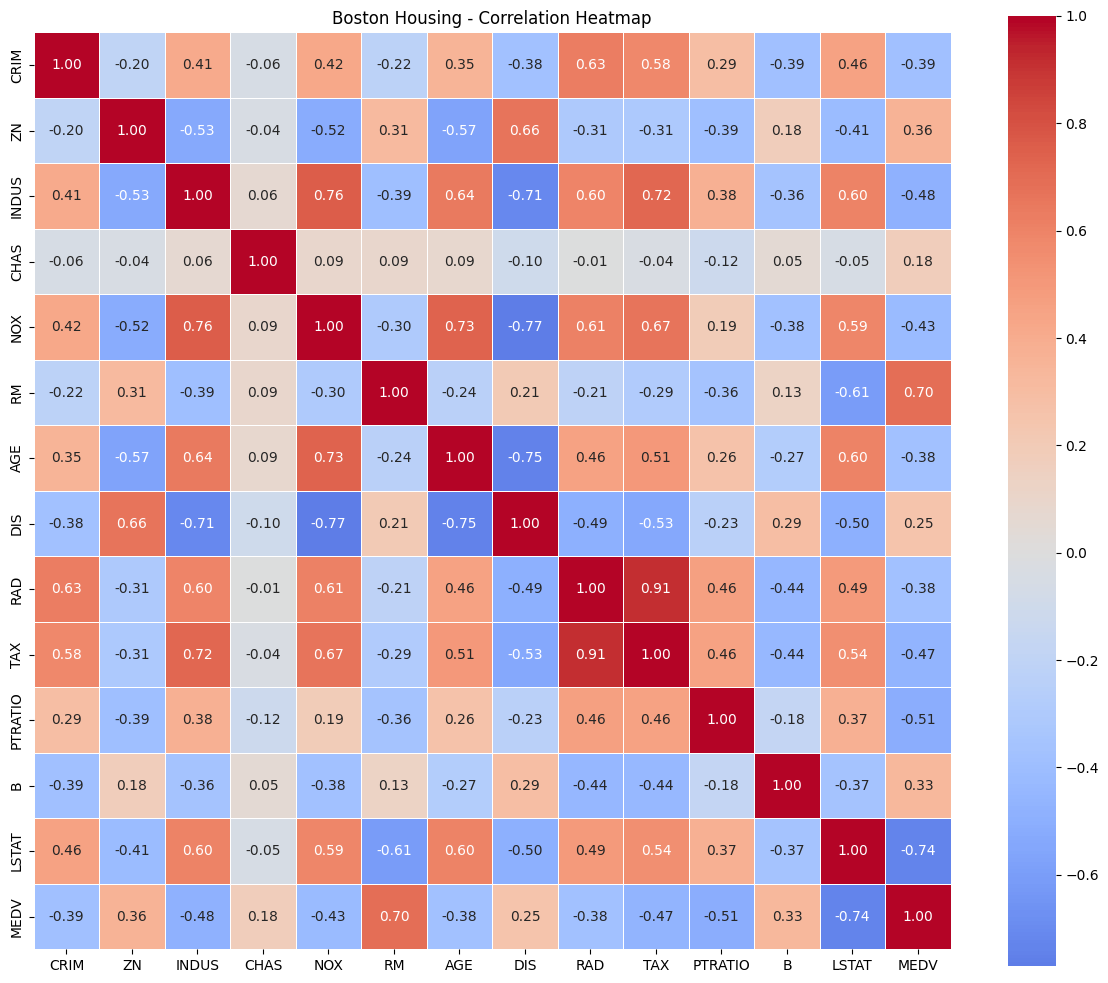

In [8]:
# 5. 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,         # 수치 표시
    fmt='.2f',          # 소수점 2자리
    cmap='coolwarm',    # 색상맵
    center=0,           # 0 기준
    square=True,
    linewidths=0.5
)
plt.title('Boston Housing - Correlation Heatmap')
plt.tight_layout()
plt.show()



In [9]:
# 6. MEDV와의 상관계수만 추출
medv_corr = corr_matrix['MEDV'].drop('MEDV').sort_values()
print(medv_corr)

LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
CHAS       0.175260
DIS        0.249929
B          0.333461
ZN         0.360445
RM         0.695360
Name: MEDV, dtype: float64


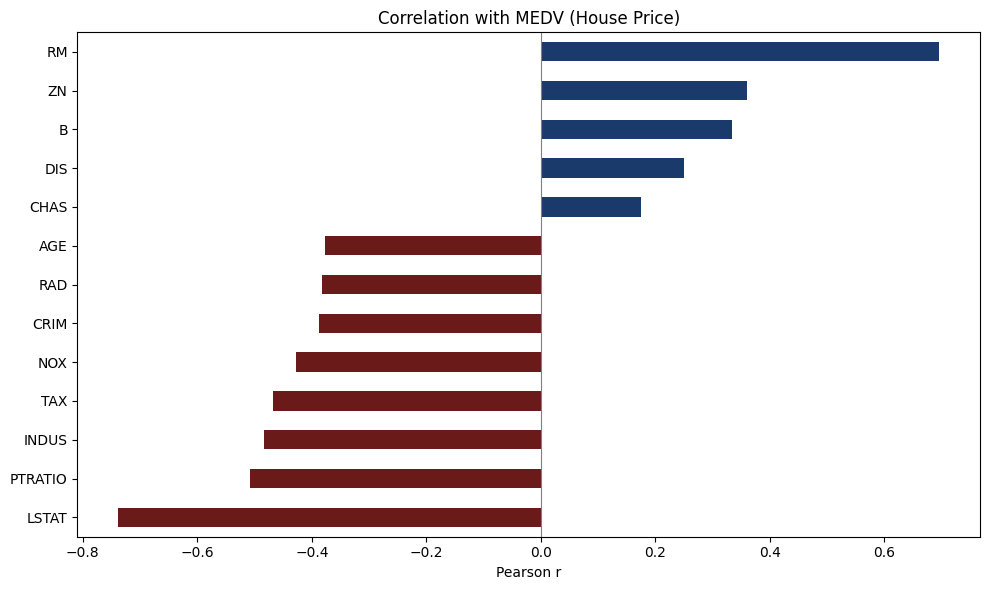

In [10]:
# 7. 막대 차트
plt.figure(figsize=(10, 6))
colors = ['#6b1a1a' if v < 0 else '#1a3a6b' for v in medv_corr]
medv_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Correlation with MEDV (House Price)')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

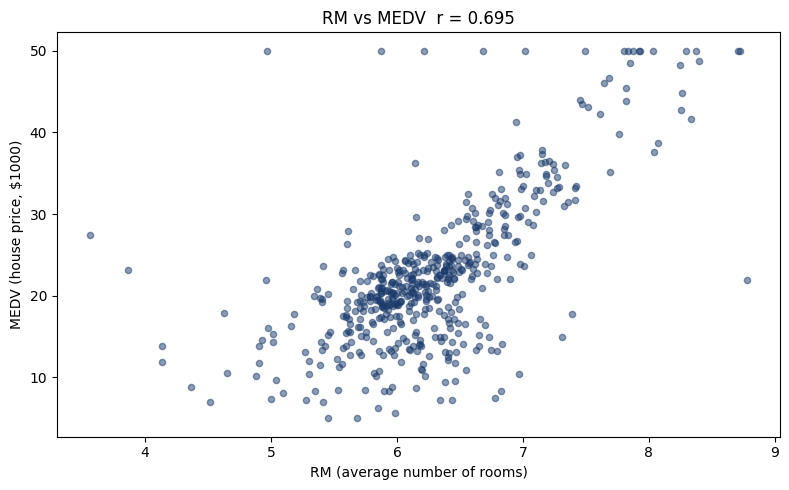

In [11]:
# 8. 산점도 (RM vs MEDV)
plt.figure(figsize=(8, 5))
plt.scatter(df['RM'], df['MEDV'], alpha=0.5, color='#1a3a6b', s=20)
plt.xlabel('RM (average number of rooms)')
plt.ylabel('MEDV (house price, $1000)')
plt.title(f"RM vs MEDV  r = {df['RM'].corr(df['MEDV']):.3f}")
plt.tight_layout()
plt.show()

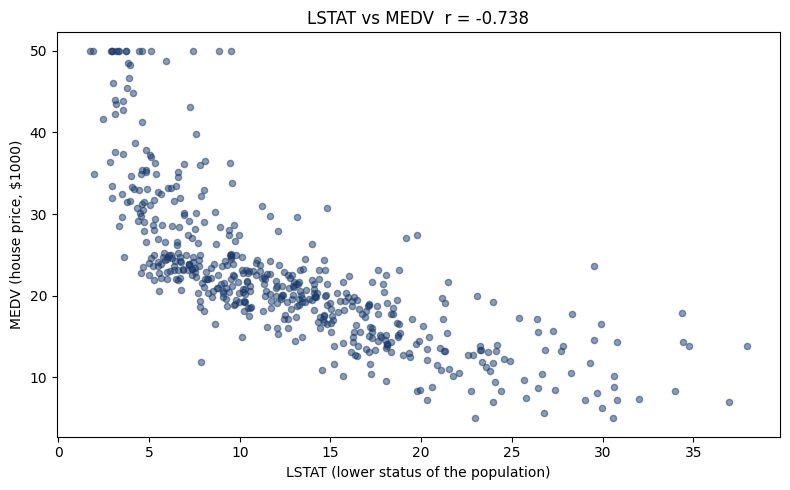

In [12]:
# 9. 산점도 (LSTAT vs MEDV)
plt.figure(figsize=(8, 5))
plt.scatter(df['LSTAT'], df['MEDV'], alpha=0.5, color='#1a3a6b', s=20)
plt.xlabel('LSTAT (lower status of the population)')
plt.ylabel('MEDV (house price, $1000)')
plt.title(f"LSTAT vs MEDV  r = {df['LSTAT'].corr(df['MEDV']):.3f}")
plt.tight_layout()
plt.show()

In [13]:
# 10. 강한 상관관계 쌍 추출 (|r| > 0.6)
threshold = 0.6
strong = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            strong.append((cols[i], cols[j], round(r, 3)))

strong_df = pd.DataFrame(strong, columns=['Var1','Var2','r'])
print(strong_df.sort_values('r', key=abs, ascending=False))

     Var1   Var2      r
15    RAD    TAX  0.910
8     NOX    DIS -0.769
2   INDUS    NOX  0.764
13    AGE    DIS -0.748
16  LSTAT   MEDV -0.738
7     NOX    AGE  0.731
5   INDUS    TAX  0.721
4   INDUS    DIS -0.708
12     RM   MEDV  0.695
10    NOX    TAX  0.668
1      ZN    DIS  0.664
3   INDUS    AGE  0.645
0    CRIM    RAD  0.626
11     RM  LSTAT -0.614
9     NOX    RAD  0.611
6   INDUS  LSTAT  0.604
14    AGE  LSTAT  0.602


# t-test

In [14]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [15]:
# 2. 데이터 로드
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [17]:
# 3. 결측치 제거 (분석 변수 기준)
df_age = df.dropna(subset=['age', 'survived'])
df_fare = df.dropna(subset=['fare', 'survived'])

# 4. 그룹 분리
survived_age = df_age[df_age['survived'] == 1]['age']
died_age     = df_age[df_age['survived'] == 0]['age']

survived_fare = df_fare[df_fare['survived'] == 1]['fare']
died_fare     = df_fare[df_fare['survived'] == 0]['fare']

print(survived_age.shape)
print(died_age.shape)
print(survived_fare.shape)
print(died_fare.shape)

(290,)
(424,)
(342,)
(549,)


In [18]:


# 5. 등분산 검정 (Levene's test)
lev_age  = stats.levene(survived_age, died_age)
lev_fare = stats.levene(survived_fare, died_fare)
print(f"Levene (Age):  F={lev_age.statistic:.3f},  p={lev_age.pvalue:.3f}")
print(f"Levene (Fare): F={lev_fare.statistic:.3f}, p={lev_fare.pvalue:.3f}")


Levene (Age):  F=1.195,  p=0.275
Levene (Fare): F=45.100, p=0.000


In [19]:

# 6. Welch's t-test (equal_var=False 권장)
t_age,  p_age  = stats.ttest_ind(survived_age, died_age, equal_var=True)
t_fare, p_fare = stats.ttest_ind(survived_fare, died_fare, equal_var=False)

print(f"\n[나이] t={t_age:.3f}, p={p_age:.3f}")
print(f"  생존자 평균: {survived_age.mean():.1f}세")
print(f"  사망자 평균: {died_age.mean():.1f}세")

print(f"\n[요금] t={t_fare:.3f}, p={p_fare:.4f}")
print(f"  생존자 평균: ${survived_fare.mean():.1f}")
print(f"  사망자 평균: ${died_fare.mean():.1f}")


[나이] t=-2.067, p=0.039
  생존자 평균: 28.3세
  사망자 평균: 30.6세

[요금] t=6.839, p=0.0000
  생존자 평균: $48.4
  사망자 평균: $22.1


In [20]:
# 7. 유의성 판단
def interpret(p):
    if p < 0.001: return "*** 매우 유의 (p<0.001)"
    elif p < 0.01: return "** 유의 (p<0.01)"
    elif p < 0.05: return "* 유의 (p<0.05)"
    else: return "유의하지 않음 (p>=0.05)"

print(f"\n나이: {interpret(p_age)}")
print(f"요금: {interpret(p_fare)}")


나이: * 유의 (p<0.05)
요금: *** 매우 유의 (p<0.001)


/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_29649/1205742348.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(['Died(0)', 'Survived(1)'])
/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_29649/1205742348.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(['Died(0)', 'Survived(1)'])


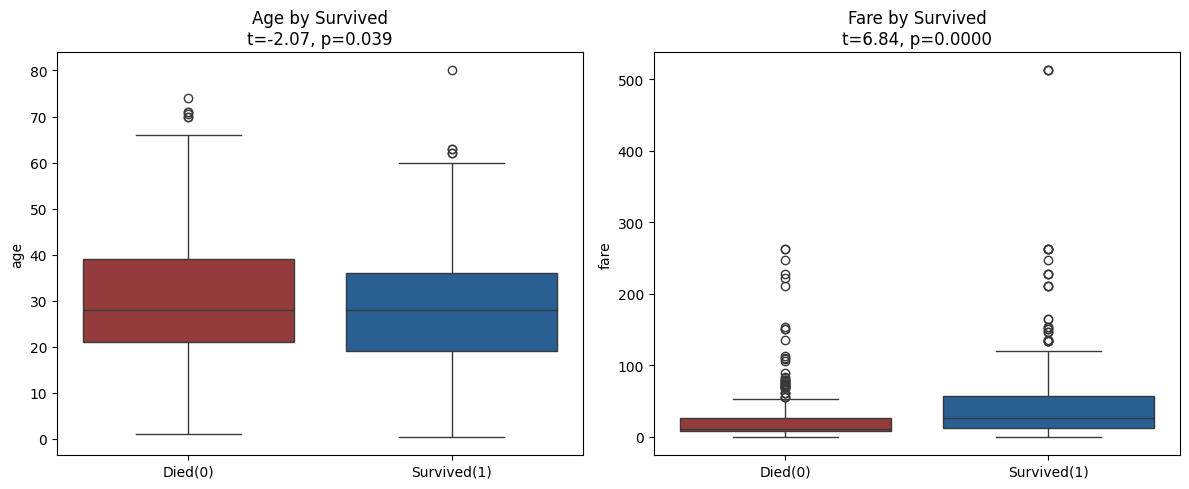

In [21]:
# 8. 박스플롯 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# survived 타입(문자/숫자) 차이로 인한 palette 매핑 오류 방지
df_age_plot = df_age.copy()
df_fare_plot = df_fare.copy()
df_age_plot['survived'] = df_age_plot['survived'].astype(str)
df_fare_plot['survived'] = df_fare_plot['survived'].astype(str)
survived_palette = {'0': '#a32d2d', '1': '#185fa5'}

sns.boxplot(
    data=df_age_plot, x='survived', y='age',
    hue='survived', palette=survived_palette,
    order=['0', '1'], hue_order=['0', '1'],
    dodge=False, legend=False, ax=axes[0]
)
axes[0].set_xticklabels(['Died(0)', 'Survived(1)'])
axes[0].set_title(f'Age by Survived\nt={t_age:.2f}, p={p_age:.3f}')
axes[0].set_xlabel('')

sns.boxplot(
    data=df_fare_plot, x='survived', y='fare',
    hue='survived', palette=survived_palette,
    order=['0', '1'], hue_order=['0', '1'],
    dodge=False, legend=False, ax=axes[1]
)
axes[1].set_xticklabels(['Died(0)', 'Survived(1)'])
axes[1].set_title(f'Fare by Survived\nt={t_fare:.2f}, p={p_fare:.4f}')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()



# ANOVA

In [22]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import duckdb

In [23]:
def esql(sql):
    return duckdb.sql(sql).df()


In [24]:
# 2. 데이터 로드
df = sns.load_dataset('iris')
features = ['sepal_length','sepal_width','petal_length','petal_width']
print(df.head())
print("\n",esql("select species, count(*) from df group by species"))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

       species  count_star()
0      setosa            50
1  versicolor            50
2   virginica            50


In [25]:

# 3. 기본 정보 확인
print(df.groupby('species')[features].mean())


            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


In [26]:

# 4. One-way ANOVA (변수별)
print("\n[One-way ANOVA 결과]")
for feat in features:
    groups = [df[df['species']==s][feat] for s in df['species'].unique()]
    F, p = stats.f_oneway(*groups)
    
    # 효과크기 eta-squared
    grand_mean = df[feat].mean()
    ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total   = sum((df[feat]-grand_mean)**2)
    eta2 = ss_between / ss_total
    
    print(f"{feat:15s} F={F:8.2f}  p={p:.4f}  η²={eta2:.3f}")

# 5. 등분산 검정 (Levene)
print("\n[Levene 등분산 검정]")
for feat in features:
    groups = [df[df['species']==s][feat] for s in df['species'].unique()]
    F, p = stats.levene(*groups)
    print(f"{feat:15s} F={F:.3f}  p={p:.3f}  {'등분산 OK' if p>0.05 else '등분산 위반'}")




[One-way ANOVA 결과]
sepal_length    F=  119.26  p=0.0000  η²=0.619
sepal_width     F=   49.16  p=0.0000  η²=0.401
petal_length    F= 1180.16  p=0.0000  η²=0.941
petal_width     F=  960.01  p=0.0000  η²=0.929

[Levene 등분산 검정]
sepal_length    F=6.353  p=0.002  등분산 위반
sepal_width     F=0.590  p=0.556  등분산 OK
petal_length    F=19.480  p=0.000  등분산 위반
petal_width     F=19.892  p=0.000  등분산 위반


In [27]:
# 6. 사후검정 — Tukey HSD (petal_length)
# Tukey HSD는 ANOVA에서 "어느 그룹 쌍이 다른가" 를 찾는 사후검정(Post-hoc test)
tukey = pairwise_tukeyhsd(
    endog=df['petal_length'],
    groups=df['species'],
    alpha=0.05
)
print("\n[Tukey HSD — petal_length]")
print(tukey)




[Tukey HSD — petal_length]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor    2.798   0.0 2.5942 3.0018   True
    setosa  virginica     4.09   0.0 3.8862 4.2938   True
versicolor  virginica    1.292   0.0 1.0882 1.4958   True
---------------------------------------------------------


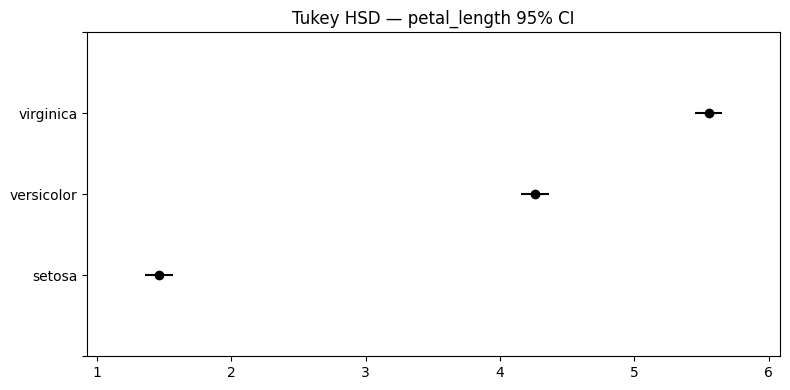

In [28]:
# 7. Tukey 결과 시각화
tukey.plot_simultaneous(figsize=(8, 4))
plt.title('Tukey HSD — petal_length 95% CI')
plt.tight_layout()
plt.show()

In [29]:
tukey = pairwise_tukeyhsd(
    endog=df['petal_width'],
    groups=df['species'],
    alpha=0.05
)
print("\n[Tukey HSD — petal_width]")
print(tukey)


[Tukey HSD — petal_width]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     1.08   0.0 0.9831 1.1769   True
    setosa  virginica     1.78   0.0 1.6831 1.8769   True
versicolor  virginica      0.7   0.0 0.6031 0.7969   True
---------------------------------------------------------


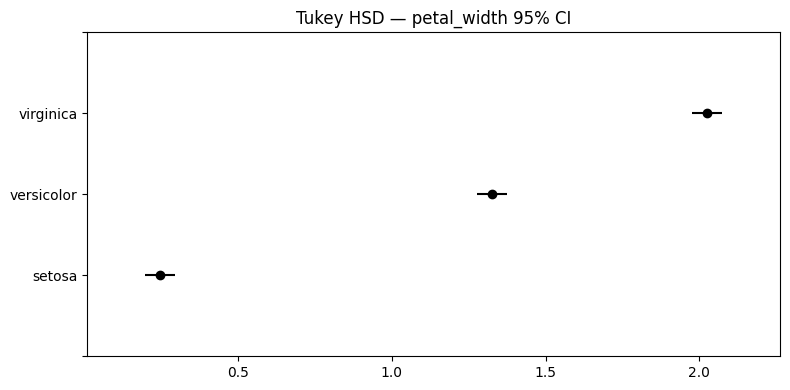

In [30]:
tukey.plot_simultaneous(figsize=(8, 4))
plt.title('Tukey HSD — petal_width 95% CI')
plt.tight_layout()
plt.show()

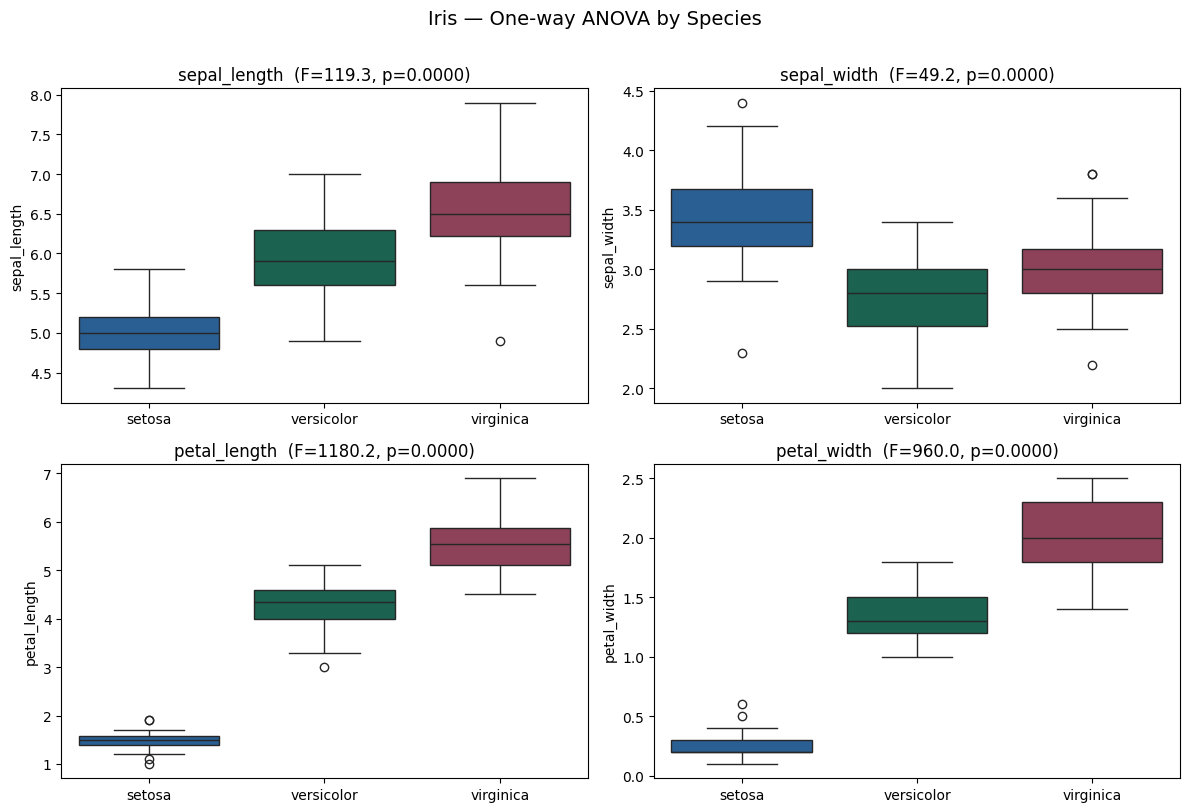

In [31]:
# 8. 박스플롯 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
palette = {'setosa':'#185fa5','versicolor':'#0f6e56','virginica':'#993556'}

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feat, hue="species",palette=palette, ax=ax)
    groups = [df[df['species']==s][feat] for s in df['species'].unique()]
    F, p = stats.f_oneway(*groups)
    ax.set_title(f'{feat}  (F={F:.1f}, p={p:.4f})')
    ax.set_xlabel('')

plt.suptitle('Iris — One-way ANOVA by Species', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()



# PCA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [33]:

# ── 1. 데이터 로드 ──────────────────────────────────────────────
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("=== Iris 데이터셋 기본 정보 ===")
print(f"Shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")
print()

=== Iris 데이터셋 기본 정보 ===
Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']



In [35]:

# ── 2. 스케일링 ─────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. PCA (전체 4개 컴포넌트) ──────────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

print("=== Explained Variance Ratio ===")
for i, (ratio, cumulative) in enumerate(zip(evr, cumulative_evr), 1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.1f}%)  |  누적: {cumulative*100:.1f}%")
print()


=== Explained Variance Ratio ===
PC1: 0.7296 (73.0%)  |  누적: 73.0%
PC2: 0.2285 (22.9%)  |  누적: 95.8%
PC3: 0.0367 (3.7%)  |  누적: 99.5%
PC4: 0.0052 (0.5%)  |  누적: 100.0%



In [36]:
# ── 4. PCA (2D 변환) ────────────────────────────────────────────
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print("=== PCA 2D 변환 결과 ===")
print(f"원본 shape: {X_scaled.shape} → 변환 후: {X_pca.shape}")
print(f"PC1 + PC2 설명력: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print()


=== PCA 2D 변환 결과 ===
원본 shape: (150, 4) → 변환 후: (150, 2)
PC1 + PC2 설명력: 95.8%



In [37]:

# ── 5. Loadings (PC와 원본 피처의 관계) ─────────────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)
print("=== Feature Loadings ===")
print(loadings.round(4))
print()

=== Feature Loadings ===
                      PC1     PC2
sepal length (cm)  0.5211  0.3774
sepal width (cm)  -0.2693  0.9233
petal length (cm)  0.5804  0.0245
petal width (cm)   0.5649  0.0669



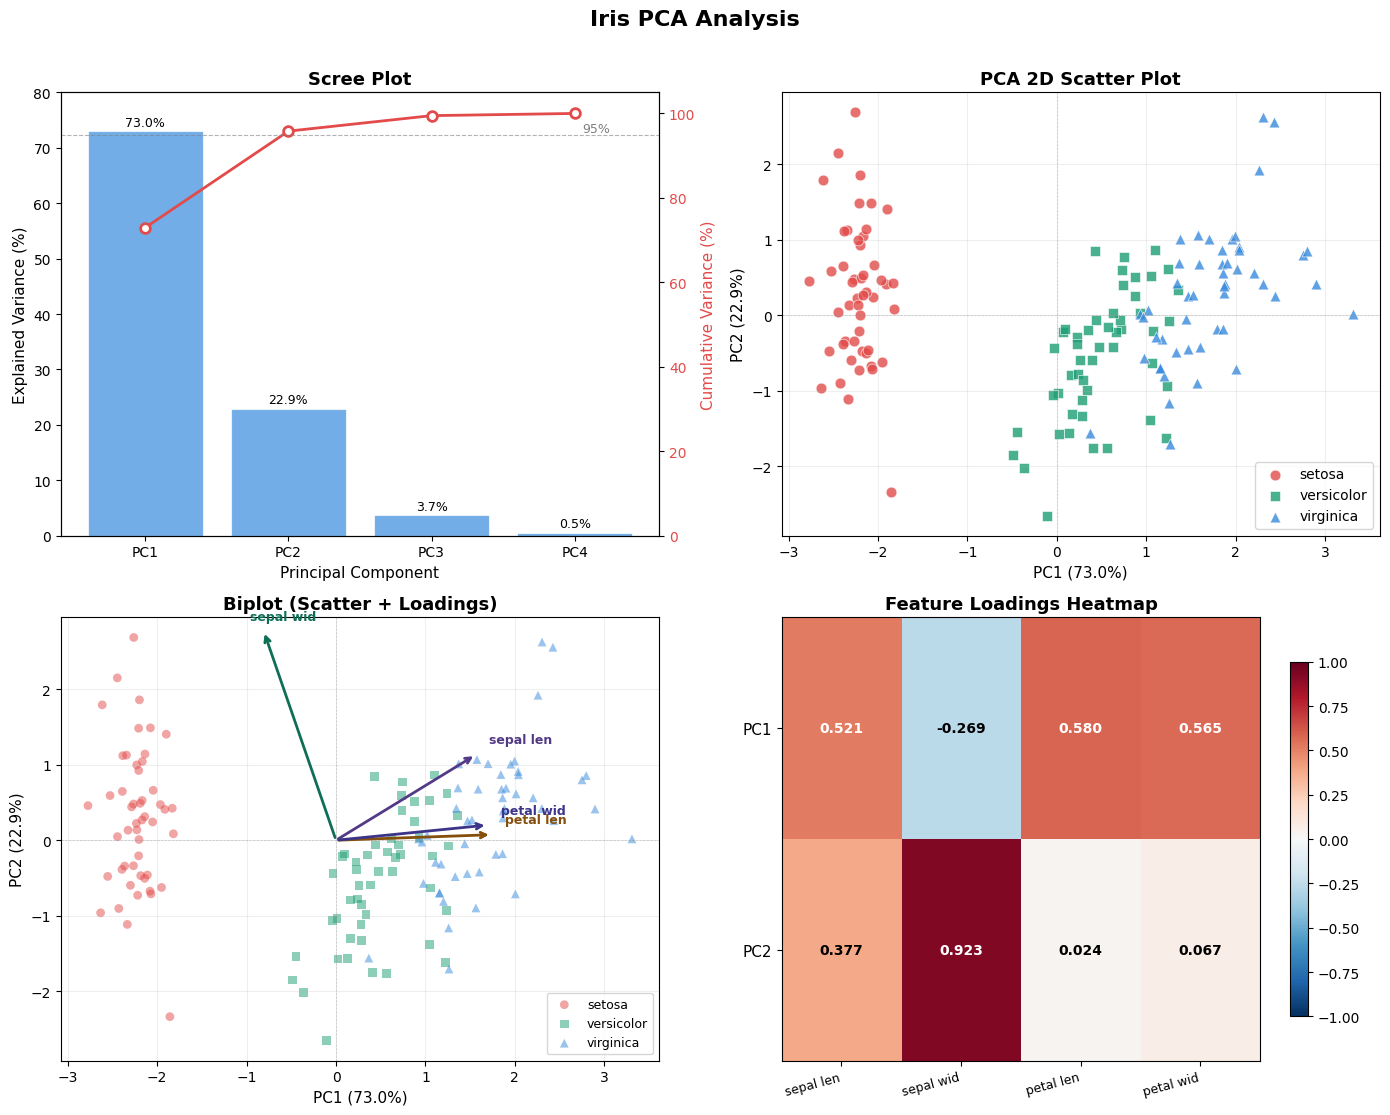


시각화 저장 완료: iris_pca_analysis.png


In [40]:
# ── 6. 시각화 (2×2 레이아웃) ───────────────────────────────────
colors = ['#E24B4A', '#1D9E75', '#378ADD']
markers = ['o', 's', '^']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Iris PCA Analysis', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Scree Plot ──────────────────────────────────────────
ax1 = axes[0, 0]
x_pos = np.arange(1, 5)
bars = ax1.bar(x_pos, evr * 100, color='#378ADD', alpha=0.7, edgecolor='white', linewidth=0.8)
ax1_twin = ax1.twinx()
ax1_twin.plot(x_pos, cumulative_evr * 100, 'o-', color='#E24B4A',
              linewidth=2, markersize=7, markerfacecolor='white', markeredgewidth=2)
ax1_twin.axhline(y=95, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1_twin.text(4.05, 95.5, '95%', fontsize=9, color='gray')

for bar, val in zip(bars, evr * 100):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance (%)', fontsize=11)
ax1_twin.set_ylabel('Cumulative Variance (%)', fontsize=11, color='#E24B4A')
ax1_twin.tick_params(axis='y', labelcolor='#E24B4A')
ax1_twin.set_ylim(0, 105)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'PC{i}' for i in x_pos])
ax1.set_title('Scree Plot', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 80)

# ── Plot 2: 2D PCA Scatter ──────────────────────────────────────
ax2 = axes[0, 1]
for i, (name, color, marker) in enumerate(zip(target_names, colors, markers)):
    mask = y == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, marker=marker, s=60, alpha=0.8,
                edgecolors='white', linewidths=0.5, label=name)

ax2.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)', fontsize=11)
ax2.set_title('PCA 2D Scatter Plot', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, framealpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
ax2.grid(True, alpha=0.2)

# ── Plot 3: Biplot (Scatter + Loadings) ─────────────────────────
ax3 = axes[1, 0]
for i, (name, color, marker) in enumerate(zip(target_names, colors, markers)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, marker=marker, s=40, alpha=0.5,
                edgecolors='none', label=name)

scale = 3.0
short_names = ['sepal len', 'sepal wid', 'petal len', 'petal wid']
arrow_colors = ['#533A87', '#0F6E56', '#854F0B', '#3C3489']

for j, (feat, sname, ac) in enumerate(zip(feature_names, short_names, arrow_colors)):
    x_load = pca_2d.components_[0, j] * scale
    y_load = pca_2d.components_[1, j] * scale
    ax3.annotate('', xy=(x_load, y_load), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=ac, lw=2))
    offset_x = 0.15 if x_load > 0 else -0.15
    offset_y = 0.15 if y_load > 0 else -0.15
    ax3.text(x_load + offset_x, y_load + offset_y, sname,
             fontsize=9, color=ac, fontweight='bold')

ax3.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)', fontsize=11)
ax3.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)', fontsize=11)
ax3.set_title('Biplot (Scatter + Loadings)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.8)
ax3.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
ax3.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
ax3.grid(True, alpha=0.2)

# ── Plot 4: Heatmap (Loadings) ──────────────────────────────────
ax4 = axes[1, 1]
loading_matrix = pca_2d.components_  # shape: (2, 4)

im = ax4.imshow(loading_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax4, shrink=0.8)

ax4.set_xticks(range(4))
ax4.set_yticks(range(2))
ax4.set_xticklabels(short_names, fontsize=9, rotation=15, ha='right')
ax4.set_yticklabels(['PC1', 'PC2'], fontsize=11)
ax4.set_title('Feature Loadings Heatmap', fontsize=13, fontweight='bold')

for i in range(2):
    for j in range(4):
        val = loading_matrix[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax4.text(j, i, f'{val:.3f}', ha='center', va='center',
                 fontsize=10, color=text_color, fontweight='bold')

plt.tight_layout()
plt.savefig('iris_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n시각화 저장 완료: iris_pca_analysis.png")